In [ ]:
#step 1 To classify an image as dog
#import libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D
from tensorflow.keras.layers import Flatten,Dense
from tensorflow.keras.datasets import cifar10
import numpy as np

In [ ]:
#step2: load dataset
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#step3: classify the dataset
y_train=np.where(y_train==5,1,0)
y_test=np.where(y_test==5,1,0)

In [ ]:
#now class1->dog
#class 0->nota dog
#step4: Normalize image

x_train=x_train/255.0
x_test=x_test/255.0

In [ ]:
#step5: building cnnmodel
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))# for binary output

In [ ]:
#step 6: compile model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# Step 7: Train the model
history = model.fit(x_train, y_train,epochs=5,batch_size=64)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.8983 - loss: 0.2958
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.9038 - loss: 0.2358
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.9109 - loss: 0.2225
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9151 - loss: 0.2119
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.9197 - loss: 0.1988


In [ ]:
#step8: evaluate model
loss,accuracy=model.evaluate(x_test,y_test)
print("Test Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9131 - loss: 0.2170
Test Accuracy: 0.9143999814987183


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


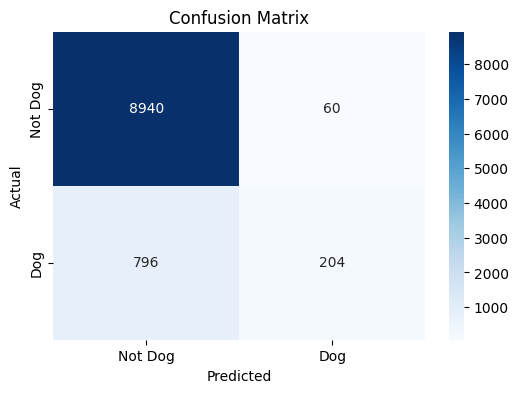

              precision    recall  f1-score   support

     Not Dog       0.92      0.99      0.95      9000
         Dog       0.77      0.20      0.32      1000

    accuracy                           0.91     10000
   macro avg       0.85      0.60      0.64     10000
weighted avg       0.90      0.91      0.89     10000



In [ ]:
#evaluate confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = (model.predict(x_test) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Dog","Dog"], yticklabels=["Not Dog","Dog"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=["Not Dog","Dog"]))


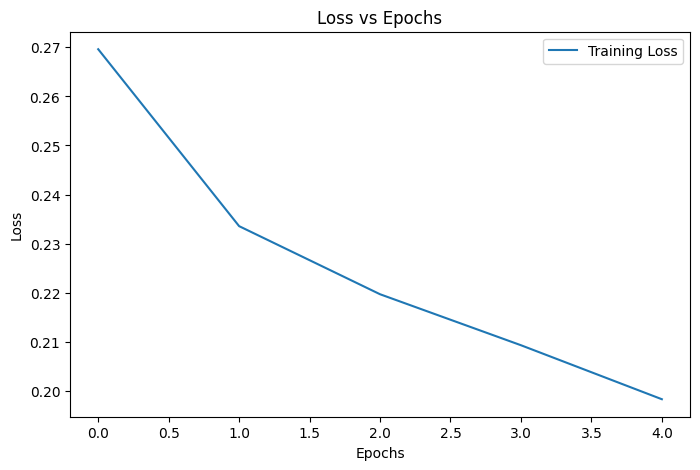

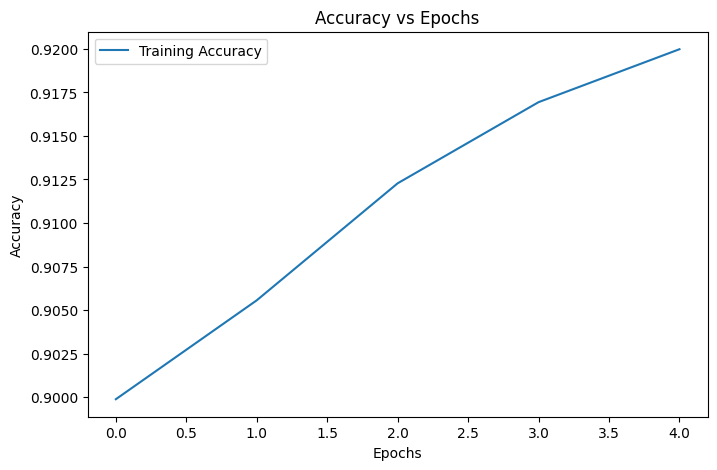

In [ ]:
#plt the graph between loss and training error
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
#tune the model and find its performance parameters
from tensorflow.keras.layers import Dropout
model_tuned = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_tuned.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

history_tuned = model_tuned.fit(x_train, y_train,epochs=10,batch_size=64,validation_data=(x_test, y_test))

test_loss, test_acc = model_tuned.evaluate(x_test, y_test, verbose=2)
print(f"Tuned Model Test Accuracy: {test_acc:.4f}")



Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 84ms/step - accuracy: 0.8988 - loss: 0.2895 - val_accuracy: 0.9045 - val_loss: 0.2540
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.9113 - loss: 0.2357 - val_accuracy: 0.9163 - val_loss: 0.2171
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.9170 - loss: 0.2145 - val_accuracy: 0.9211 - val_loss: 0.2025
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 79ms/step - accuracy: 0.9234 - loss: 0.1997 - val_accuracy: 0.9228 - val_loss: 0.1956
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.9266 - loss: 0.1860 - val_accuracy: 0.9265 - val_loss: 0.1891
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.9303 - loss: 0.1801 - val_accuracy: 0.9297 - val_loss: 0.1788
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.9339 - loss: 0.1706 - val_accuracy: 0.9318 - val_loss: 0.1828
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 82ms/step - accuracy: 0.9354 - loss: 0.1619 - 

In [ ]:
print(classification_report(y_test, y_pred, target_names=["Not Dog","Dog"]))


              precision    recall  f1-score   support

     Not Dog       0.92      0.99      0.95      9000
         Dog       0.77      0.20      0.32      1000

    accuracy                           0.91     10000
   macro avg       0.85      0.60      0.64     10000
weighted avg       0.90      0.91      0.89     10000

